# COSC 4337 - Homework 1: Perceptron & Stability Analysis 


**Objective:** Implement the Perceptron and Pocket algorithms. You must demonstrate the **instability** of the standard Perceptron on noisy data and prove how the Pocket algorithm solves this by plotting the accuracy stability over time.

**Note:** Use `NumPy` for all model logic. `scikit-learn` is allowed only for data generation. You may use Tensorflow or Pytorch for future assignments as you see fit.

In [4]:
# === Import Libraries ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons

# === Set Seed ===
seed = 4337
np.random.seed(seed)

## Part 1: Implement the Models

**Requirement:** 
1. `Perceptron`: You must track `self.acc_history_` (a list of accuracy scores at the end of every epoch) in addition to errors.
2. `PocketPerceptron`: You must track `self.pocket_history_` (the best accuracy currently stored in the pocket at every epoch).

In [5]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=50, random_state=1):
        self.eta = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.errors_ = []
        self.acc_history_ = [] # TODO: Populate this in fit()

    def fit(self, X, y):
        # YOUR CODE HERE: 
        # 1. Initialize weights using a random normal distribution (use self.random_state).
        # 2. Implement the update loop.
        # 3. Append the accuracy on X to self.acc_history_ at the end of EVERY epoch.
        randomNormalDistro = np.random.RandomState(self.random_state)
        self.weights = randomNormalDistro.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.bias = 0.0
        self.errors_ = []
        self.acc_history_ = []
        for _ in range(self.n_iters):
            errors = 0
            for i, target in zip(X, y):
                update = self.eta * (target - self.predict(i))
                self.weights += update * i
                self.bias += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            self.acc_history_.append(np.mean(self.predict(X) == y))
        return self

    def net_input(self, X):
        # YOUR CODE HERE: z = w.x + b
        return np.dot(X, self.weights) + self.bias

    def predict(self, X):
        # YOUR CODE HERE: 1 if z >= 0 else 0
        return np.where(self.net_input(X) >= 0.0, 1, 0)

class PocketPerceptron(Perceptron):
    def __init__(self, learning_rate=0.01, n_iters=50, random_state=1):
        super().__init__(learning_rate, n_iters, random_state)
        self.w_best = None
        self.b_best = None
        self.best_accuracy = 0.0
        self.pocket_history_ = [] # TODO: Populate this

    def fit(self, X, y):
        # YOUR CODE HERE: 
        # Inherit/Modify fit() to update self.w_best whenever current accuracy > self.best_accuracy.
        # IMPORTANT: Append 'self.best_accuracy' to 'self.pocket_history_' at every epoch.
        randomNormalDistro = np.random.RandomState(self.random_state)
        self.weights = randomNormalDistro.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.bias = 0.0
        self.errors_ = []
        self.acc_history_ = []
        self.pocket_history_ = []
        self.w_best = self.weights.copy()
        self.b_best = self.bias
        self.best_accuracy = 0.0
        for _ in range(self.n_iters):
            errors = 0
            for i, target in zip(X, y):
                update = self.eta * (target - self.predict(i))
                self.weights += update * i
                self.bias += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
            currentAccuracy = np.mean(self.predict(X) == y)
            self.acc_history_.append(currentAccuracy)
            if currentAccuracy > self.best_accuracy:
                self.best_accuracy = currentAccuracy
                self.w_best = self.weights.copy()
                self.b_best = self.bias
            self.pocket_history_.append(self.best_accuracy)
        self.weights = self.w_best.copy()
        self.bias = self.b_best
        return self

## Part 2: Experimental Setup

We use `cluster_std=2.2`. This creates data that is *mostly* separable but has enough overlap to confuse a standard linear classifier.

In [6]:
# Generate Data
X_noisy, y_noisy = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=2.2, random_state=seed)

# Visualization Helper (Pre-written for you)
def plot_decision_regions(X, y, classifier, title="Decision Boundary"):
    resolution = 0.02
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap='coolwarm')
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    scatter = plt.scatter(x=X[:, 0], y=X[:, 1], alpha=0.8, c=y, cmap='coolwarm', edgecolor='black', s=50)
    plt.title(title)
    plt.legend(*scatter.legend_elements(), loc="upper left", title="Classes")
    plt.show()

## Part 3: Analysis Tasks

### Task 3.1: Convergence Analysis
Train a `Perceptron` on `X_noisy` for 50 epochs using `learning_rate=0.01`. 
**Deliverable:** Plot **Epochs vs. Errors**. Does the number of errors ever hit 0? Why or why not?

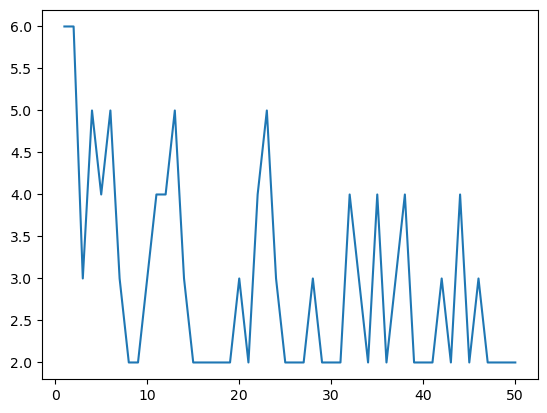

In [ ]:
# YOUR CODE HERE
perceptron = Perceptron(learning_rate=0.01, n_iters=50)
perceptron.fit(X_noisy, y_noisy)
plt.plot(range(1, len(perceptron.errors_) + 1), perceptron.errors_)
plt.show()
# It does not it 0 because the 2 classes overlap.

### Task 3.2: Stability Analysis 
We want to see how the "best known solution" evolves over time.

**Experiment:**
1. Train a `Perceptron` for 100 epochs on `X_noisy`.
2. Train a `PocketPerceptron` for 100 epochs on `X_noisy`.

**Deliverable:**
Create a single plot overlaying two lines:
1. The `acc_history_` of the Standard Perceptron (Blue).
2. The `pocket_history_` of the Pocket Perceptron (Orange).

**Analysis Question:** 
Describe the behavior of the blue line. Why does it fluctuate? Describe the orange line. Why does it never go down?

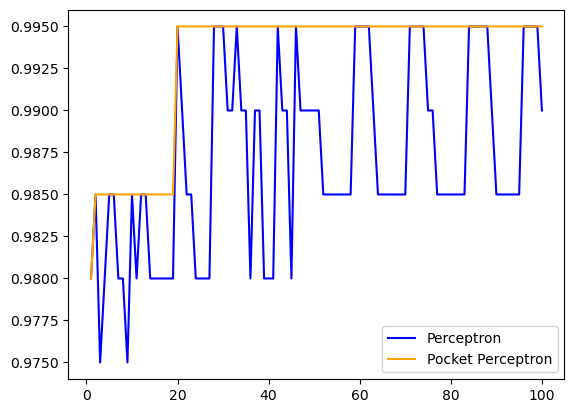

In [ ]:
# YOUR CODE HERE
perceptron = Perceptron(learning_rate=0.01, n_iters=100)
perceptron.fit(X_noisy, y_noisy)
pocketPerceptron = PocketPerceptron(learning_rate=0.01, n_iters=100)
pocketPerceptron.fit(X_noisy, y_noisy)
plt.plot(range(1, 101), perceptron.acc_history_, color="blue", label="Perceptron")
plt.plot(range(1, 101), pocketPerceptron.pocket_history_, color="orange", label="Pocket Perceptron")
plt.legend()
plt.show()
# The blue line goes up and down because the classes overlap.
# The orange line never decreases because it stores a new solution when accurancy improves.

### Task 3.3: Visual Confirmation
Plot the final decision boundaries for both models from Task 3.2.
You should notice that the Pocket Perceptron's boundary looks more "sensible" (centering the cut) than the Standard Perceptron, which might have stopped at a random "bad" epoch.

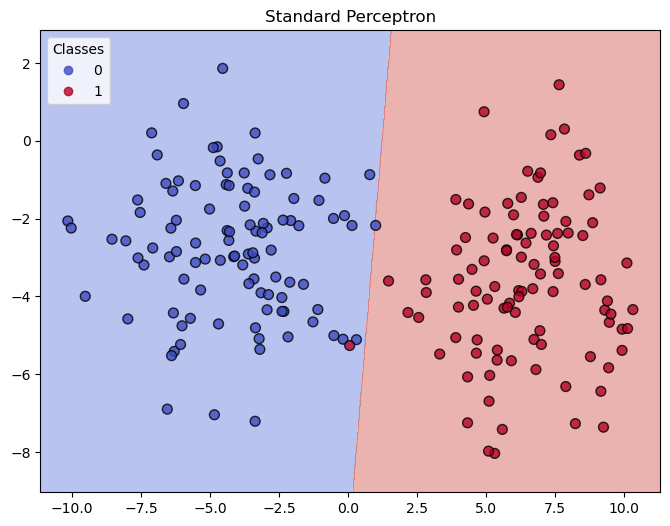

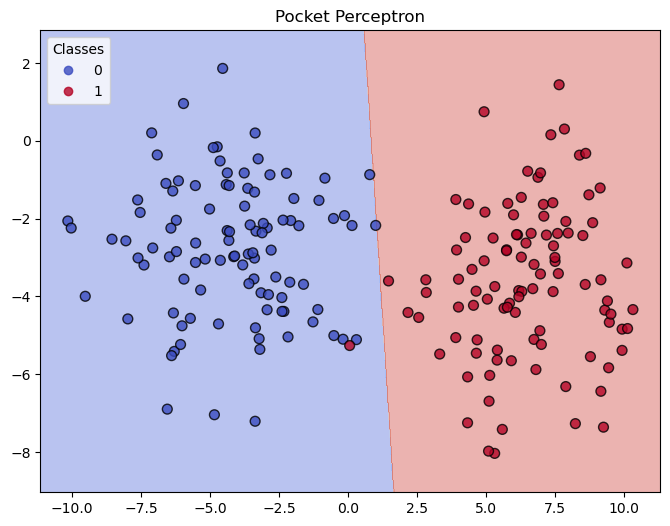

In [13]:
# YOUR CODE HERE
plot_decision_regions(X_noisy, y_noisy, perceptron, title="Standard Perceptron")
plot_decision_regions(X_noisy, y_noisy, pocketPerceptron, title="Pocket Perceptron")

## Part 4: The XOR Limit
Demonstrate why we need Multi-Layer Perceptrons.
**Deliverable:** Train a model on `X_moons` and visualize the decision boundary.

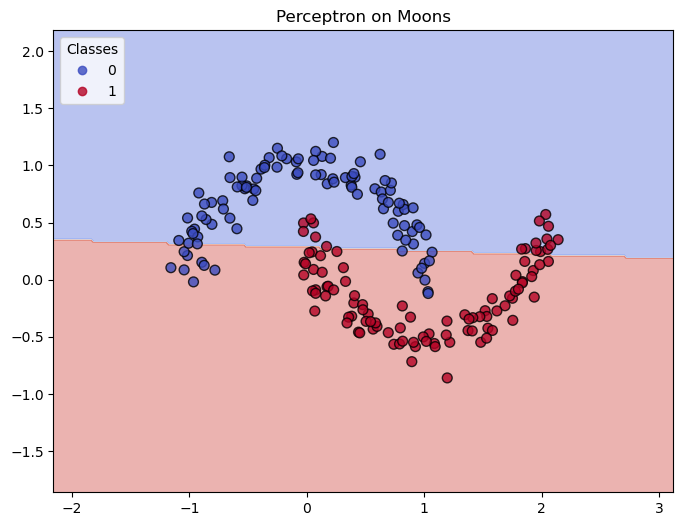

In [14]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=seed)
# YOUR CODE HERE
moonPerceptron = Perceptron(learning_rate=0.01, n_iters=100)
moonPerceptron.fit(X_moons, y_moons)
plot_decision_regions(X_moons, y_moons, moonPerceptron, title="Perceptron on Moons")

## 5. Deliverables
1. Submit the `.ipynb` and HTML file. 25% penalty for not doing so.
2. Ensure you have submitted the file with all solutions visible. 25% penalty for not doing so.